In [1]:
import pandas as pb

In [3]:
df = pb.read_csv('placement.csv')

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape

(100, 4)

In [6]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [7]:
# Preprocess
df = df.iloc[:, 1:] #To remove Unmaned column

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
import matplotlib.pyplot as plt

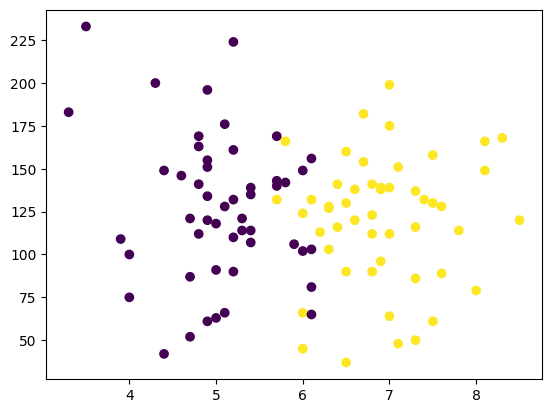

In [10]:
#Generating Scatter Plot with cgpa in X-axis, iq in Y-axis, and color-coded placement result
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

In [12]:
#In this dataset, cgpa and iq are independent varaibales and placement is a dependent variable
## 1. Extract input and output cols
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [13]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [15]:
##Train test split
#Here 0.1 represents that 10% of dataset will go fo testing and remaining 90% will go for training
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [16]:
X_train

,cgpa,iq
16,5.2,224.0
43,6.8,141.0
80,4.9,196.0
18,4.0,100.0
70,6.3,127.0
...,...,...
34,4.8,163.0
77,7.3,50.0
5,7.1,48.0
37,8.1,149.0


In [17]:
y_train

,placement
16,0
43,1
80,0
18,0
70,1
...,...
34,0
77,1
5,1
37,1


In [18]:
X_test

,cgpa,iq
42,7.6,89.0
57,6.5,130.0
22,4.9,120.0
24,4.7,121.0
3,7.4,132.0
27,6.0,124.0
8,6.1,156.0
25,5.0,91.0
50,3.5,233.0
94,4.7,52.0


In [19]:
# 2. Scale the values - transforms the data points to lie between -1 to 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)

In [21]:
X_train

array([[-0.74142286,  2.57336862],
       [ 0.68782603,  0.4492732 ],
       [-1.00940703,  1.85680631],
       [-1.81335953, -0.59997876],
       [ 0.24118575,  0.09099204],
       [-0.29478258,  0.42368168],
       [ 0.33051381,  0.4492732 ],
       [ 0.77715409,  0.39809017],
       [-0.56276675, -0.24169761],
       [ 0.24118575,  0.11658355],
       [-0.02679842, -1.47009014],
       [-0.02679842, -2.00751188],
       [ 2.20640298, -0.08814854],
       [-0.74142286, -0.34406365],
       [-0.65209481, -0.06255703],
       [-1.00940703,  0.80755435],
       [-0.29478258,  0.2189496 ],
       [ 1.58110659, -0.24169761],
       [-1.00940703,  0.27013262],
       [ 0.86648214,  0.39809017],
       [-1.18806314, -0.93266841],
       [ 0.41984186, -2.21224396],
       [ 0.50916992, -0.08814854],
       [-1.45604731, -2.08428641],
       [ 1.13446631, -0.19051458],
       [ 1.31312242, -1.5980477 ],
       [-0.92007897, -1.54686467],
       [-1.45604731,  0.65400529],
       [ 0.59849797,

In [22]:
X_test = scaler.transform(X_test)

In [23]:
X_test

array([[ 1.40245048, -0.88148538],
       [ 0.41984186,  0.16776657],
       [-1.00940703, -0.08814854],
       [-1.18806314, -0.06255703],
       [ 1.22379436,  0.2189496 ],
       [-0.02679842,  0.01421751],
       [ 0.06252964,  0.83314586],
       [-0.92007897, -0.83030236],
       [-2.25999981,  2.80369222],
       [-1.18806314, -1.8283713 ]])

In [24]:
#4. Train the model - using Logistic Regression (used to divide dataset)
from sklearn.linear_model import LogisticRegression

In [25]:
clf = LogisticRegression()

In [26]:
#model training
clf.fit(X_train,y_train)

LogisticRegression()

In [27]:
#model evaluation
#predict() gives the results on X_test imput
y_pred = clf.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score
#accuracy_score() compares the generated results with y_test dataset and gives accuracy percentage
accuracy_score(y_test, y_pred)

0.9

In [29]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

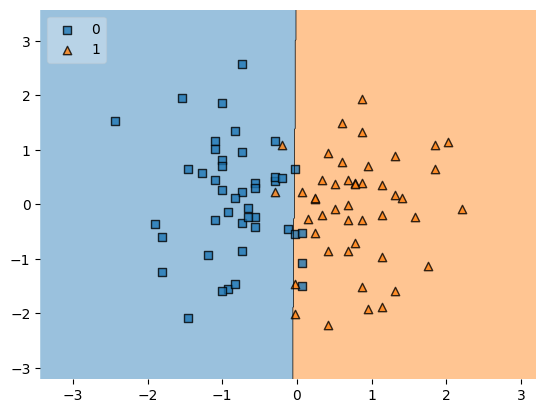

In [30]:
#To plot the line that divides the dataset
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [31]:
# pickle converts object into file, which can be deployed in an environment
import pickle

In [33]:
# 'wb' means write binary mode
pickle.dump(clf,open('model.pkl','wb'))